In [21]:
import pandas as pd
import re
from textblob import TextBlob
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("mh_wilds_reviews.csv")

In [6]:
# Function to clean text
def clean_text(text):
    
    # Ensure text is present
    if not isinstance(text, str):
        return ""
    
    # Lowercase all text
    text = text.lower()
    
    # Regex to remove anything that is not lowercase or a space
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Reduce extra spaces to one
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [7]:
df['clean_review'] = df['review'].apply(clean_text)

print(df.head())

   recommendationid                                             author  \
0         220315355  {'steamid': '76561198009891744', 'personaname'...   
1         220314783  {'steamid': '76561197961501391', 'personaname'...   
2         220311563  {'steamid': '76561199139817326', 'personaname'...   
3         220310583  {'steamid': '76561198080201950', 'personaname'...   
4         220307095  {'steamid': '76561198129551405', 'personaname'...   

  language                                             review  \
0  english  Runs great. No stuttering, lag or crashes.\r\n...   
1  english  its alright wish i had friends to play with pr...   
2  english  This game would be peak if it was actually opt...   
3  english                                   It good now.\r\n   
4  english  [h1]Comprehnsive, spoiler-free review of Monst...   

   timestamp_created  timestamp_updated  voted_up  votes_up  votes_funny  \
0         1773103075         1773103075      True         0            0   
1         17

In [8]:
# Create function to find text sentiment
def get_sentinment(text):
    
    if not text:
        return 0.0
    
    analysis = TextBlob(text)
    
    score = analysis.sentiment.polarity
    
    return score

In [9]:
# Run get_sentiment over df["clean_review"]
df["sentiment_score"] = df["clean_review"].apply(get_sentinment)

# Check to see if it worked
print(df[['clean_review', 'sentiment_score']].head(10))

                                        clean_review  sentiment_score
0  runs great no stuttering lag or crashes the ab...         0.062500
1  its alright wish i had friends to play with pr...        -0.131250
2  this game would be peak if it was actually opt...        -0.200000
3                                        it good now         0.700000
4  hcomprehnsive spoilerfree review of monster hu...        -0.048295
5                                     love this game         0.050000
6                                           its cool         0.350000
7                                                yes         0.000000
8                                                yes         0.000000
9  cant even play minutes without it crashingsham...        -0.200000


In [10]:
# Calculate the mean sentiment score
average_sentiment = df["sentiment_score"].mean()

print(average_sentiment)

0.10385197363093861


In [11]:
# Find scores that indicate moderate or higher positivity towards the game
positive_scores_df = df[df["sentiment_score"] > 0.1]

total_positive = len(positive_scores_df)

print(total_positive)

# Find scores that indicate moderate or higher negativity towards the game
negative_scores_df = df[df["sentiment_score"] < -0.1]

total_negative = len(negative_scores_df)

print(total_negative)

406
126


In [14]:
# Use NLTK stopwords for NLP use later
nltk_stop_words = set(stopwords.words('english'))

print(nltk_stop_words)

{'will', 'which', 'd', 'yours', 'doing', 'doesn', 'should', "shan't", 'through', 'can', 'before', 'it', 'again', 'about', 'by', 'who', "i've", 'myself', 'those', 'him', 'ours', "we've", 'so', 'and', 'won', 'a', 'during', 'your', 'his', 'the', 'any', 'very', 'if', 'out', "you're", 'at', 'weren', 'you', 'shan', 'being', 'from', 'o', 'yourselves', "needn't", 'their', 'does', 'over', 'they', "it'd", 'are', 'we', 'yourself', 'were', 'while', "i'll", 'theirs', "aren't", 'to', "should've", 'other', 'ma', 'why', 'be', "you'll", 'in', 'both', "they've", 'each', 'below', "he'd", 'on', "doesn't", 'has', 'or', "he'll", 'ourselves', "she'll", "didn't", 'now', 'don', "don't", 'after', 'itself', 't', 'more', 'further', 'them', "we'll", 'do', 'having', 'against', 'did', 'herself', 'then', 'when', 'needn', 'is', "couldn't", 'than', 'there', "mightn't", 'down', 'haven', 'our', 'me', 'nor', 'until', "i'd", 've', "hadn't", 'its', "she'd", 'these', 'been', 's', 'aren', 'above', "won't", 'whom', "you've", "

In [15]:
# Add in custom stop words for MHWilds
custom_stops = {
    'game', 'games', 'play', 'playing', 'played', 
    'monster', 'hunter', 'wilds', 'capcom', 
    'im', 'like', 'just', 'get', 'even', 'really', 'would',
    "dont", "know"
}

# Combine them into one
stop_words = nltk_stop_words.union(custom_stops)

In [16]:
# Turn negative_scores_df to join all text for NLP to find all words in negative
# reviews
negative_string = " ".join(negative_scores_df["clean_review"])

all_negative_words = negative_string.split()

# Filter out stop words
filtered_negative_words = [word for word in all_negative_words
                           if word not in stop_words]
word_pairs = list(ngrams(filtered_negative_words, 2))

negative_counter = Counter(word_pairs)

print(negative_counter.most_common(10))

[(('waste', 'money'), 3), (('make', 'playable'), 3), (('ryzen', 'x'), 3), (('performance', 'updates'), 3), (('master', 'rank'), 3), (('took', 'year'), 3), (('graphics', 'drivers'), 3), (('x', 'ntdlldllxffbbe'), 3), (('cant', 'wait'), 2), (('since', 'release'), 2)]


In [26]:
x_labels = []
y_labels = []

for pair, count in negative_counter.most_common(10):
    
    formatted_pair = " ".join(pair)
    
    x_labels.append(formatted_pair)
    
    y_labels.append(count)

print(x_labels)
print(y_labels)

['waste money', 'make playable', 'ryzen x', 'performance updates', 'master rank', 'took year', 'graphics drivers', 'x ntdlldllxffbbe', 'cant wait', 'since release']
[3, 3, 3, 3, 3, 3, 3, 3, 2, 2]


Chart generated and saved as top_complaints.png.


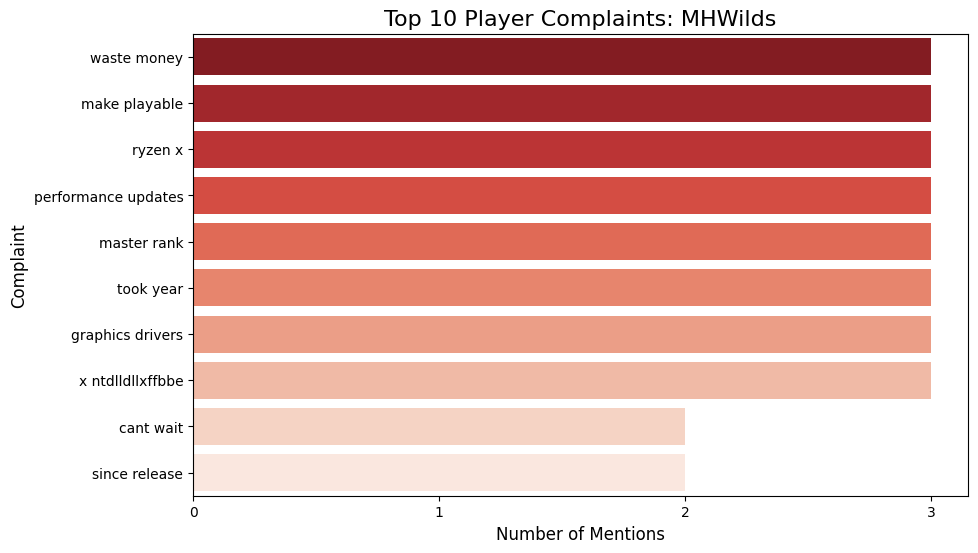

In [35]:
max_count = max(y_labels)

# Create figure for negative counters
plt.figure(figsize=(10,6))

sns.barplot(x=y_labels, y=x_labels, palette="Reds_r", hue=x_labels)

plt.title("Top 10 Player Complaints: MHWilds", fontsize=16)
plt.xlabel("Number of Mentions", fontsize=12)
plt.ylabel("Complaint", fontsize=12)

plt.xticks(range(0, max_count + 1, 1))

plt.savefig("top_complaints.png", bbox_inches="tight")

print("Chart generated and saved as top_complaints.png.")